In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/fake-news-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-news-detection-dataset' dataset.
Path to dataset files: /kaggle/input/fake-news-detection-dataset


### Explanation: Downloading the Dataset
This cell imports the `kagglehub` library and uses it to programmatically download the "Fake News Detection Dataset" from Kaggle. It stores and prints the local path where the dataset's files are downloaded.

In [ ]:
import pandas as pd
pat1 = path+"/fake_news_dataset.csv"

df = pd.read_csv(pat1)
df

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake
...,...,...,...,...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,2024-12-04,BBC,Gary Miles,Entertainment,fake
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,2024-05-26,Daily News,Maria Mcbride,Entertainment,real
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,2023-04-17,BBC,Kristen Franklin,Entertainment,real
19998,School wide itself item.,term point general common training watch respo...,2024-06-30,Reuters,David Wise,Health,fake


### Explanation: Loading the Data
This cell reads the downloaded CSV dataset into a Pandas DataFrame using the path generated in the previous step, and previews the loaded data.

In [ ]:
df.isnull().sum()

,0
title,0
text,0
date,0
source,1000
author,1000
category,0
label,0


### Explanation: Checking for Missing Values
This cell counts and displays the number of missing (NaN) values in each column of the DataFrame to identify columns that require data cleaning.

In [ ]:
# Missing values fill
df['source'] = df['source'].fillna('Unknown')
df['author'] = df['author'].fillna('Unknown')

# Check missing values again
print(df.isnull().sum())

title       0
text        0
date        0
source      0
author      0
category    0
label       0
dtype: int64


### Explanation: Handling Missing Values
This cell fills missing values in the `source` and `author` columns with the placeholder string `'Unknown'` and verifies that there are no longer any missing values in the dataset.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Explanation: Checking for Duplicate Rows
This cell calculates and outputs the number of identical duplicate rows in the DataFrame to ensure the uniqueness of our data points.

In [ ]:
df['content'] = (
    df['text'].astype(str) + ' ' +
    df['source'].astype(str) + ' ' +
    df['author'].astype(str) + ' ' +
    df['category'].astype(str)
)

print(df[['content', 'label']].head())

                                             content label
0  more tax development both store agreement lawy...  real
1  probably guess western behind likely next inve...  fake
2  them identify forward present success risk sev...  fake
3  phone which item yard Republican safe where po...  fake
4  wonder myself fact difficult course forget exa...  fake


### Explanation: Feature Engineering - Creating Combined Text
This cell concatenates the text content, source, author, and category columns together into a single comprehensive string field named `content` to leverage metadata during modeling.

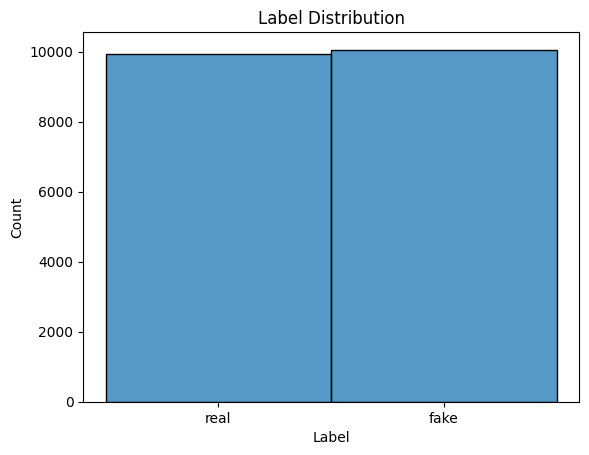

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='label', discrete=True)

plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

### Explanation: Visualizing Label Distribution
This cell uses Seaborn and Matplotlib to create a histogram showing the balance of target labels (`real` vs. `fake`) in the dataset.

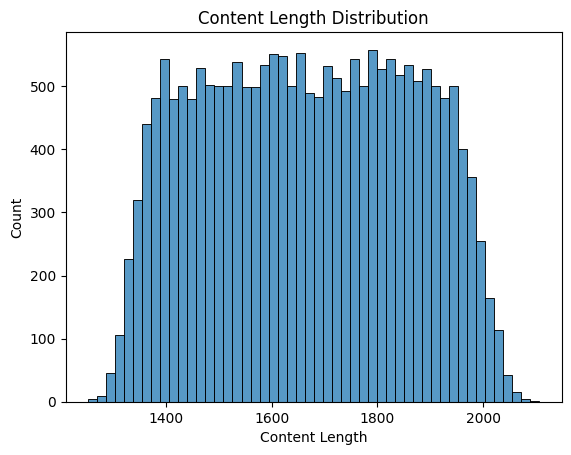

In [ ]:
df['content_length'] = df['content'].str.len()

sns.histplot(df['content_length'], bins=50)

plt.title('Content Length Distribution')
plt.xlabel('Content Length')
plt.ylabel('Count')
plt.show()

### Explanation: Analyzing Document Lengths
This cell computes the character length of the combined `content` feature and visualizes its distribution using a histogram to understand document length variance.

In [ ]:
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())

                                           title  \
0  Society image vote these realize prevent can.   
1           Red offer dream again specific case.   
2                     Item nearly develop green.   
3             Behavior stop billion PM song own.   
4         Only charge box time spend want woman.   

                                                text        date  \
0  better fall appear measure few prepare billion...  2024-04-23   
1  such east party truth place take tough stuff b...  2024-04-23   
2  here she wind budget impact who painting role ...  2023-01-02   
3  better community begin town it case but operat...  2023-04-29   
4  career court employee whatever religious secon...  2025-03-30   

         source          author    category label  \
0  Global Times  William Bolton     Science  real   
1  The Guardian    Dennis Reyes  Technology  real   
2       Reuters     Marcus Cook      Sports  fake   
3           BBC   Lori Anderson    Business  real   
4  Global Tim

### Explanation: Shuffling the Dataset
This cell randomly shuffles the rows in the DataFrame (and resets the row indices) using a set seed to ensure unbiased patterns during model training.

In [ ]:
df = df.drop(columns=['date'])

print(df.columns)

Index(['title', 'text', 'source', 'author', 'category', 'label', 'content',
       'content_length'],
      dtype='object')


### Explanation: Feature Selection
This cell drops the `date` column from the DataFrame, as date features are not being utilized in our current text classification setup.

In [ ]:
import re

def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_content'] = df['content'].apply(clean_text)

print(df[['content', 'clean_content']].head())

                                             content  \
0  better fall appear measure few prepare billion...   
1  such east party truth place take tough stuff b...   
2  here she wind budget impact who painting role ...   
3  better community begin town it case but operat...   
4  career court employee whatever religious secon...   

                                       clean_content  
0  better fall appear measure few prepare billion...  
1  such east party truth place take tough stuff b...  
2  here she wind budget impact who painting role ...  
3  better community begin town it case but operat...  
4  career court employee whatever religious secon...  


### Explanation: Text Cleaning Function
This cell defines and applies a comprehensive text-cleaning function that converts strings to lowercase, removes URLs, strips HTML tags, filters out punctuation/special characters, and normalizes whitespaces.

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

df['tokens'] = df['clean_content'].apply(
    lambda x: nltk.word_tokenize(x)
)

print(df[['clean_content', 'tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                       clean_content  \
0  better fall appear measure few prepare billion...   
1  such east party truth place take tough stuff b...   
2  here she wind budget impact who painting role ...   
3  better community begin town it case but operat...   
4  career court employee whatever religious secon...   

                                              tokens  
0  [better, fall, appear, measure, few, prepare, ...  
1  [such, east, party, truth, place, take, tough,...  
2  [here, she, wind, budget, impact, who, paintin...  
3  [better, community, begin, town, it, case, but...  
4  [career, court, employee, whatever, religious,...  


### Explanation: Tokenization
This cell downloads NLTK's word tokenization resource and splits the cleaned string sentences into individual word tokens for linguistic processing.

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

print(df[['clean_content', 'tokens']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                       clean_content  \
0  better fall appear measure few prepare billion...   
1  such east party truth place take tough stuff b...   
2  here she wind budget impact who painting role ...   
3  better community begin town it case but operat...   
4  career court employee whatever religious secon...   

                                              tokens  
0  [better, fall, appear, measure, prepare, billi...  
1  [east, party, truth, place, take, tough, stuff...  
2  [wind, budget, impact, painting, role, occur, ...  
3  [better, community, begin, town, case, operati...  
4  [career, court, employee, whatever, religious,...  


### Explanation: Stop Words Removal
This cell downloads English stop words via NLTK and filters out standard common words (e.g., 'the', 'is', 'at') from the tokenized sequences since they carry minimal classification signal.

In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                       clean_content  \
0  better fall appear measure few prepare billion...   
1  such east party truth place take tough stuff b...   
2  here she wind budget impact who painting role ...   
3  better community begin town it case but operat...   
4  career court employee whatever religious secon...   

                                              tokens  
0  [better, fall, appear, measure, prepare, billi...  
1  [east, party, truth, place, take, tough, stuff...  
2  [wind, budget, impact, painting, role, occur, ...  
3  [better, community, begin, town, case, operati...  
4  [career, court, employee, whatever, religious,...  


### Explanation: Lemmatization
This cell utilizes WordNet's Lemmatizer to reduce tokenized words back to their dictionary base forms (e.g., converting 'running' to 'run', or 'cats' to 'cat').

In [ ]:
df['processed_text'] = df['tokens'].apply(
    lambda x: ' '.join(x)
)

print(df[['tokens', 'processed_text']].head())

                                              tokens  \
0  [better, fall, appear, measure, prepare, billi...   
1  [east, party, truth, place, take, tough, stuff...   
2  [wind, budget, impact, painting, role, occur, ...   
3  [better, community, begin, town, case, operati...   
4  [career, court, employee, whatever, religious,...   

                                      processed_text  
0  better fall appear measure prepare billion inc...  
1  east party truth place take tough stuff behind...  
2  wind budget impact painting role occur life en...  
3  better community begin town case operation sto...  
4  career court employee whatever religious secon...  


### Explanation: Joining Tokens back into Strings
This cell joins the processed individual word tokens back together with spaces to reconstruct a clean string ready for standard vectorizers like TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)



Shape of X: (20000, 2409)


### Explanation: Initializing TF-IDF Vectorizer
This cell initializes Scikit-learn's `TfidfVectorizer` capped at the top 5000 feature terms to map text into numerical importance vectors.

In [ ]:
X = tfidf.fit_transform(df['processed_text'])
y = df['label']

### Explanation: Fitting TF-IDF Vectorizer
This cell transforms the textual `processed_text` into a sparse TF-IDF feature matrix `X` and targets the classification column `label` into `y`.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# X - Text Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['processed_text'])

# y - Label Encoding
le = LabelEncoder()

y = le.fit_transform(df['label'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 2409)
y shape: (20000,)


### Explanation: Feature & Label Preprocessing
This cell handles both text vectorization using TF-IDF and label encoding using `LabelEncoder` to translate categorical labels (e.g., 'fake'/'real') into binary values (0/1).

In [ ]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


### Explanation: Initializing XGBoost Classifier
This cell configures and instantiates an XGBoost classifier with custom hyperparameters (such as learning rate, tree depth, and estimators) for training.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Split the already vectorized feature matrix 'X' and encoded labels 'y'
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Train the XGBoost model
xgb_model.fit(X_train, y_train)

# 3. Prediction
y_pred = xgb_model.predict(X_test)

# 4. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.49625


### Explanation: Model Training and Evaluation (TF-IDF)
This cell splits the TF-IDF features and encoded labels into training and validation sets, trains the XGBoost model on the training fold, makes validation predictions, and measures accuracy.

In [ ]:
!pip install gensim

import numpy as np
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ==========================================
# 1. WORD2VEC MODEL
# ==========================================

w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)


# ==========================================
# 2. DOCUMENT VECTOR FUNCTION
# ==========================================

def document_vector(tokens, model):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# ==========================================
# 3. CREATE X USING WORD2VEC
# ==========================================

X = np.array([
    document_vector(tokens, w2v_model)
    for tokens in df['tokens']
])

print("X Shape:", X.shape)


# ==========================================
# 4. LABEL ENCODING
# ==========================================

le = LabelEncoder()

y = le.fit_transform(df['label'])

print("Y Shape:", y.shape)

print("Label Mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


# ==========================================
# 5. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 54.1 MB/s eta 0:00:00
X Shape: (20000, 100)
Y Shape: (20000,)
Label Mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
X_train: (16000, 100)
X_test : (4000, 100)
y_train: (16000,)
y_test : (4000,)


### Explanation: Word2Vec Word Embeddings Setup
This cell installs gensim, trains a continuous skip-gram Word2Vec representation model, averages word vectors to generate aggregate document-level features, encodes target labels, and executes a stratified train-test split.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.49625


### Explanation: Word2Vec Model Evaluation
This cell evaluates the trained classifier's classification accuracy based on the document embeddings generated using the Word2Vec model.